In [12]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from PIL import Image


In [13]:
# --- 1. CONFIGURATION AND HYPERPARAMETERS ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
DATA_ROOT = './data'  # Directory to download/load data

Using device: cuda


In [14]:
# --- 2. U-NET MODEL DEFINITION ---
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet, self).__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

In [15]:
# --- 3. CORRECTED DATASET HANDLING ---
class PetDataset(OxfordIIITPet):
    def __init__(self, root, split, transform, download):
        super().__init__(root=root, split=split, target_types="segmentation", download=download)
        self.transform = transform
        self.mask_resizer = transforms.Resize((IMG_HEIGHT, IMG_WIDTH), interpolation=transforms.InterpolationMode.NEAREST)

    def __getitem__(self, index):
        image_path = self._images[index]
        mask_path = self._segs[index]

        # Image processing
        image = self.transform(Image.open(image_path).convert("RGB"))

        # Mask processing (Corrected Logic)
        mask = Image.open(mask_path)
        mask = self.mask_resizer(mask)
        mask = np.array(mask)
        # Create binary mask: 1 for pet, 0 for background/border
        binary_mask = (mask == 1).astype(np.float32)
        mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0)

        return image, mask_tensor

In [16]:
# --- 4. UTILITY FUNCTIONS ---
def plot_metrics(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Training Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Dice Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [17]:
def visualize_results(model, dataloader, device, num_images=5):
    model.eval()
    fig = plt.figure(figsize=(15, num_images * 5))
    with torch.no_grad():
        inputs, masks = next(iter(dataloader))
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = (torch.sigmoid(outputs) > 0.5).cpu()

        for j in range(min(num_images, len(inputs))):
            # Undo normalization for display
            input_image = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            input_image = std * input_image + mean
            input_image = np.clip(input_image, 0, 1)

            ax = plt.subplot(num_images, 3, j * 3 + 1)
            ax.axis('off')
            ax.set_title('Input Image')
            plt.imshow(input_image)
            ax = plt.subplot(num_images, 3, j * 3 + 2)
            ax.axis('off')
            ax.set_title('Ground Truth Mask')
            plt.imshow(masks.data[j].squeeze(), cmap='gray')
            ax = plt.subplot(num_images, 3, j * 3 + 3)
            ax.axis('off')
            ax.set_title('Predicted Mask')
            plt.imshow(preds.data[j].squeeze(), cmap='gray')
    plt.tight_layout()
    plt.show()
    model.train()

In [18]:
# --- 5. TRAINING AND EVALUATION LOOP ---
def dice_accuracy(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()
    return (2. * intersection + smooth) / (union + smooth)

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(num_epochs):
        model.train()
        running_loss, running_accuracy = 0.0, 0.0
        for inputs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            inputs, masks = inputs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_accuracy += dice_accuracy(outputs, masks).item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_accuracy = running_accuracy / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_accuracy)

        model.eval()
        val_loss, val_accuracy = 0.0, 0.0
        with torch.no_grad():
            for inputs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                inputs, masks = inputs.to(device), masks.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * inputs.size(0)
                val_accuracy += dice_accuracy(outputs, masks).item() * inputs.size(0)

        val_loss /= len(val_loader.dataset)
        val_accuracy /= len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs} -> Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

    return history

In [19]:
# Data Transformations
transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create full dataset
full_dataset = PetDataset(root=DATA_ROOT, split="trainval", transform=transform, download=True)

# Split into training and validation sets
val_percent = 0.1
n_val = int(len(full_dataset) * val_percent)
n_train = len(full_dataset) - n_val
train_set, val_set = random_split(full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))


In [20]:
# Dataloaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)



--- Displaying sample images and ground truth masks for verification ---


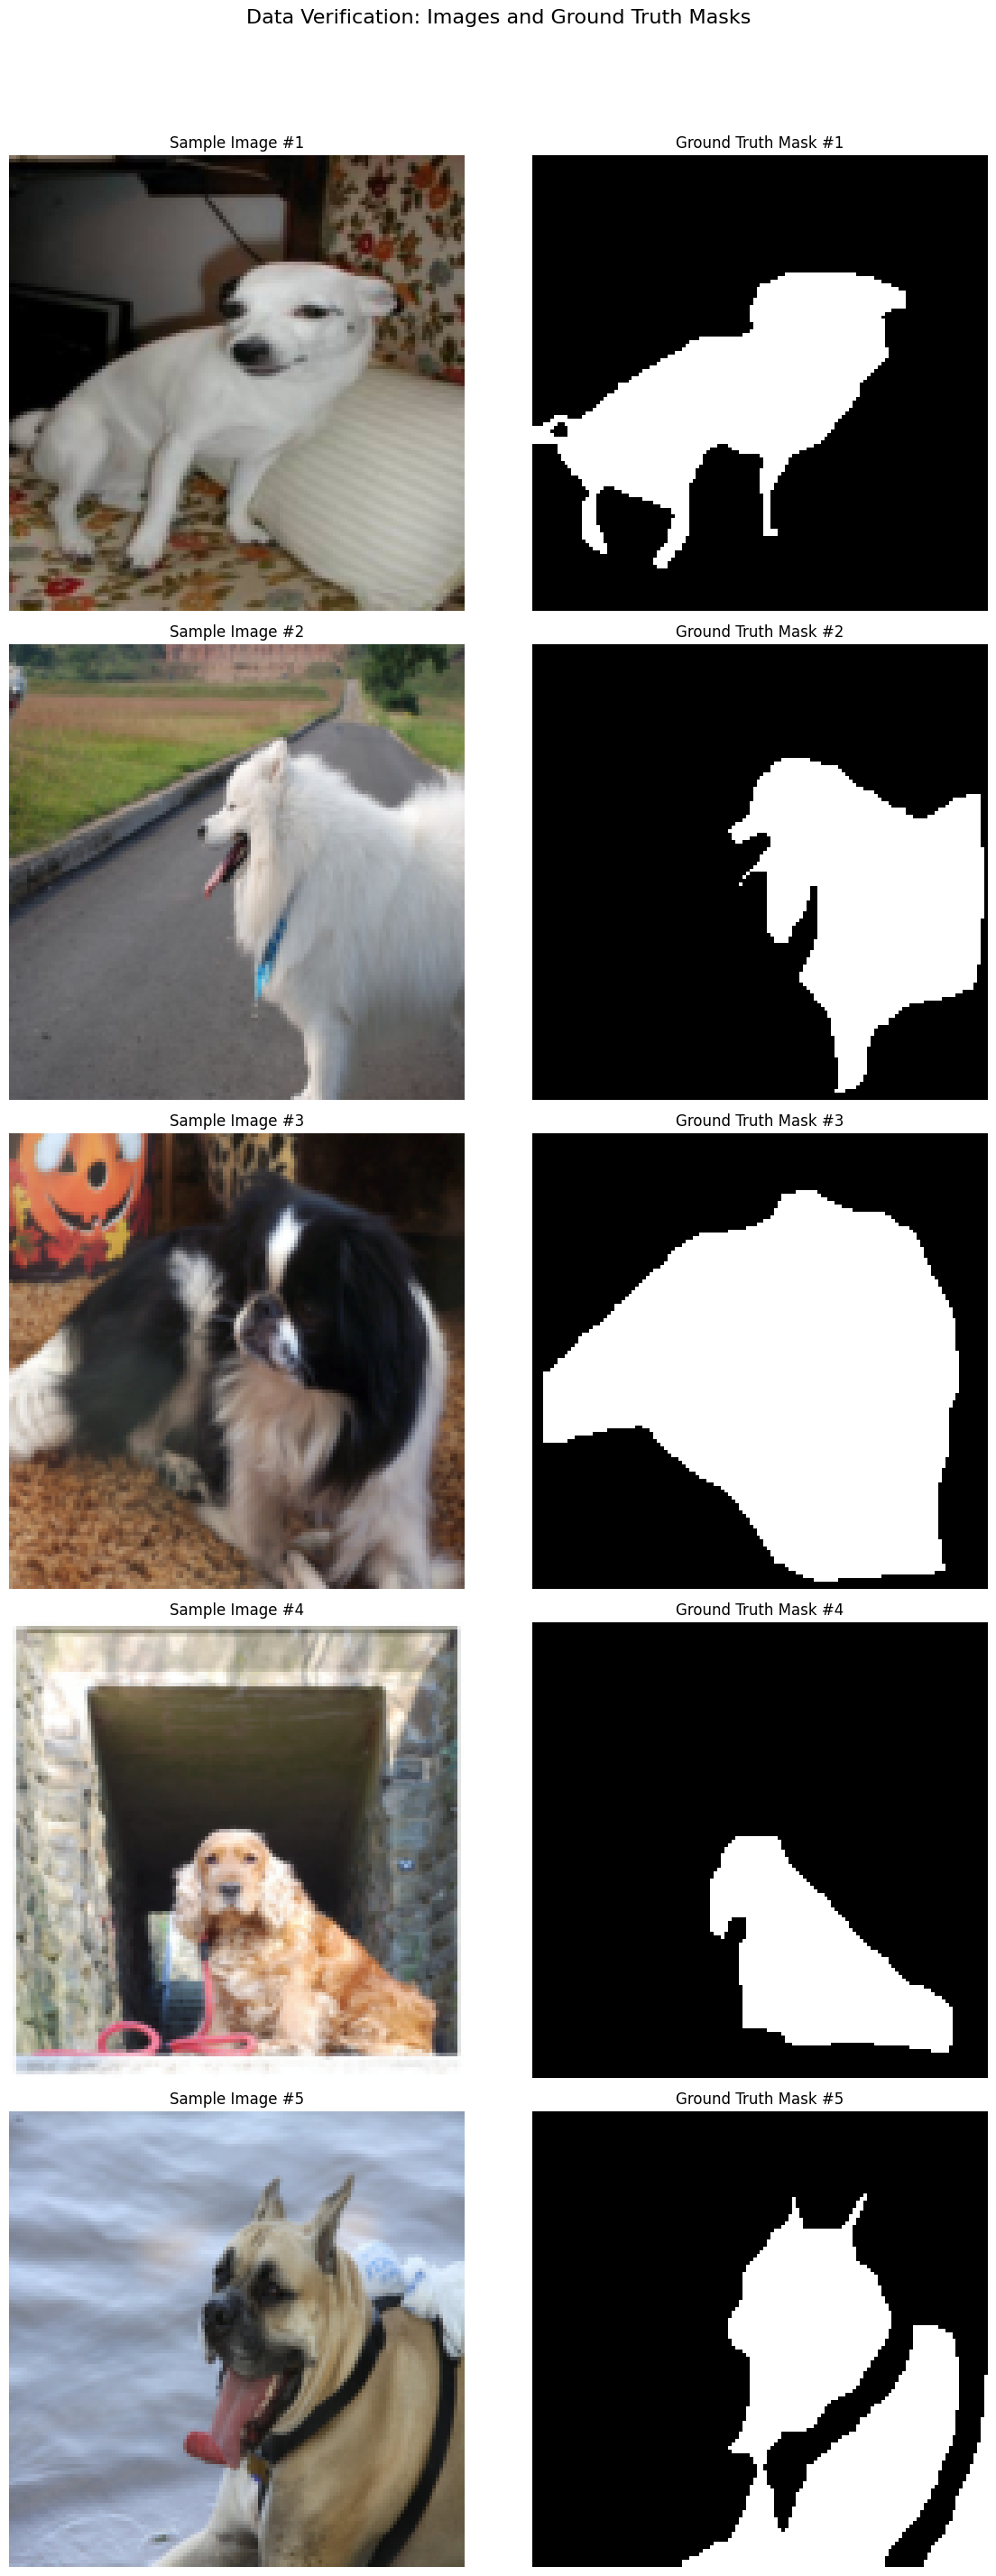

In [21]:
# --- [NEW] DATA VERIFICATION BLOCK ---
print("\n--- Displaying sample images and ground truth masks for verification ---")
inputs, masks = next(iter(val_loader))
num_images_to_show = 5
plt.figure(figsize=(12, 6 * num_images_to_show))
plt.suptitle("Data Verification: Images and Ground Truth Masks", fontsize=16)
for i in range(num_images_to_show):
    input_image_tensor = inputs[i].cpu()
    input_image = input_image_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    input_image = std * input_image + mean
    input_image = np.clip(input_image, 0, 1)
    mask_tensor = masks[i].cpu().squeeze()
    plt.subplot(num_images_to_show, 2, 2 * i + 1)
    plt.axis('off'); plt.title(f"Sample Image #{i+1}"); plt.imshow(input_image)
    plt.subplot(num_images_to_show, 2, 2 * i + 2)
    plt.axis('off'); plt.title(f"Ground Truth Mask #{i+1}"); plt.imshow(mask_tensor, cmap='gray')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [22]:
# Initialize Model, Loss, and Optimizer
model = UNet(n_channels=3, n_classes=1, bilinear=True).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Train the model
print("\n--- Starting Model Training ---")
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=NUM_EPOCHS)


--- Starting Model Training ---


Epoch 1/20 [Val]: 100%|██████████| 6/6 [00:02<00:00,  2.61it/s]


Epoch 1/20 -> Train Loss: 0.4233, Train Acc: 0.6977 | Val Loss: 0.3749, Val Acc: 0.7524


Epoch 2/20 [Val]: 100%|██████████| 6/6 [00:02<00:00,  2.58it/s]


Epoch 2/20 -> Train Loss: 0.3165, Train Acc: 0.7940 | Val Loss: 0.2966, Val Acc: 0.8091


...

Epoch 18/20 -> Train Loss: 0.0760, Train Acc: 0.9549 | Val Loss: 0.1999, Val Acc: 0.8812


Epoch 19/20 [Val]: 100%|██████████| 6/6 [00:02<00:00,  2.51it/s]


Epoch 19/20 -> Train Loss: 0.0707, Train Acc: 0.9580 | Val Loss: 0.2045, Val Acc: 0.8815


Epoch 20/20 [Val]: 100%|██████████| 6/6 [00:02<00:00,  2.54it/s]

Epoch 20/20 -> Train Loss: 0.0672, Train Acc: 0.9598 | Val Loss: 0.2170, Val Acc: 0.8737



--- Plotting Training and Validation Metrics ---


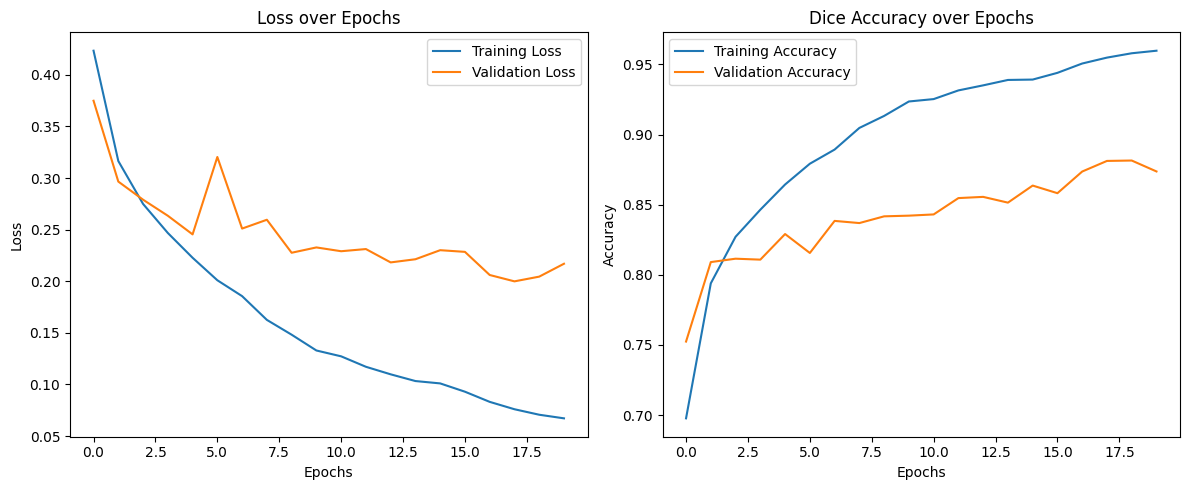

In [23]:
# Plot training metrics
print("\n--- Plotting Training and Validation Metrics ---")
plot_metrics(history)


--- Preparing the Test Dataset ---
Successfully loaded 3669 images for testing.

--- Starting Final Evaluation ---


Evaluating on Test Set: 100%|██████████| 58/58 [00:18<00:00,  3.06it/s]


--- Test Set Evaluation Summary ---
Dice Score (F1):    0.8647
IoU (Jaccard):      0.7626
Pixel Accuracy:     0.9219
Precision:          0.8788
Recall:             0.8519
-----------------------------------

--- Visualizing Model Predictions on the Test Set ---


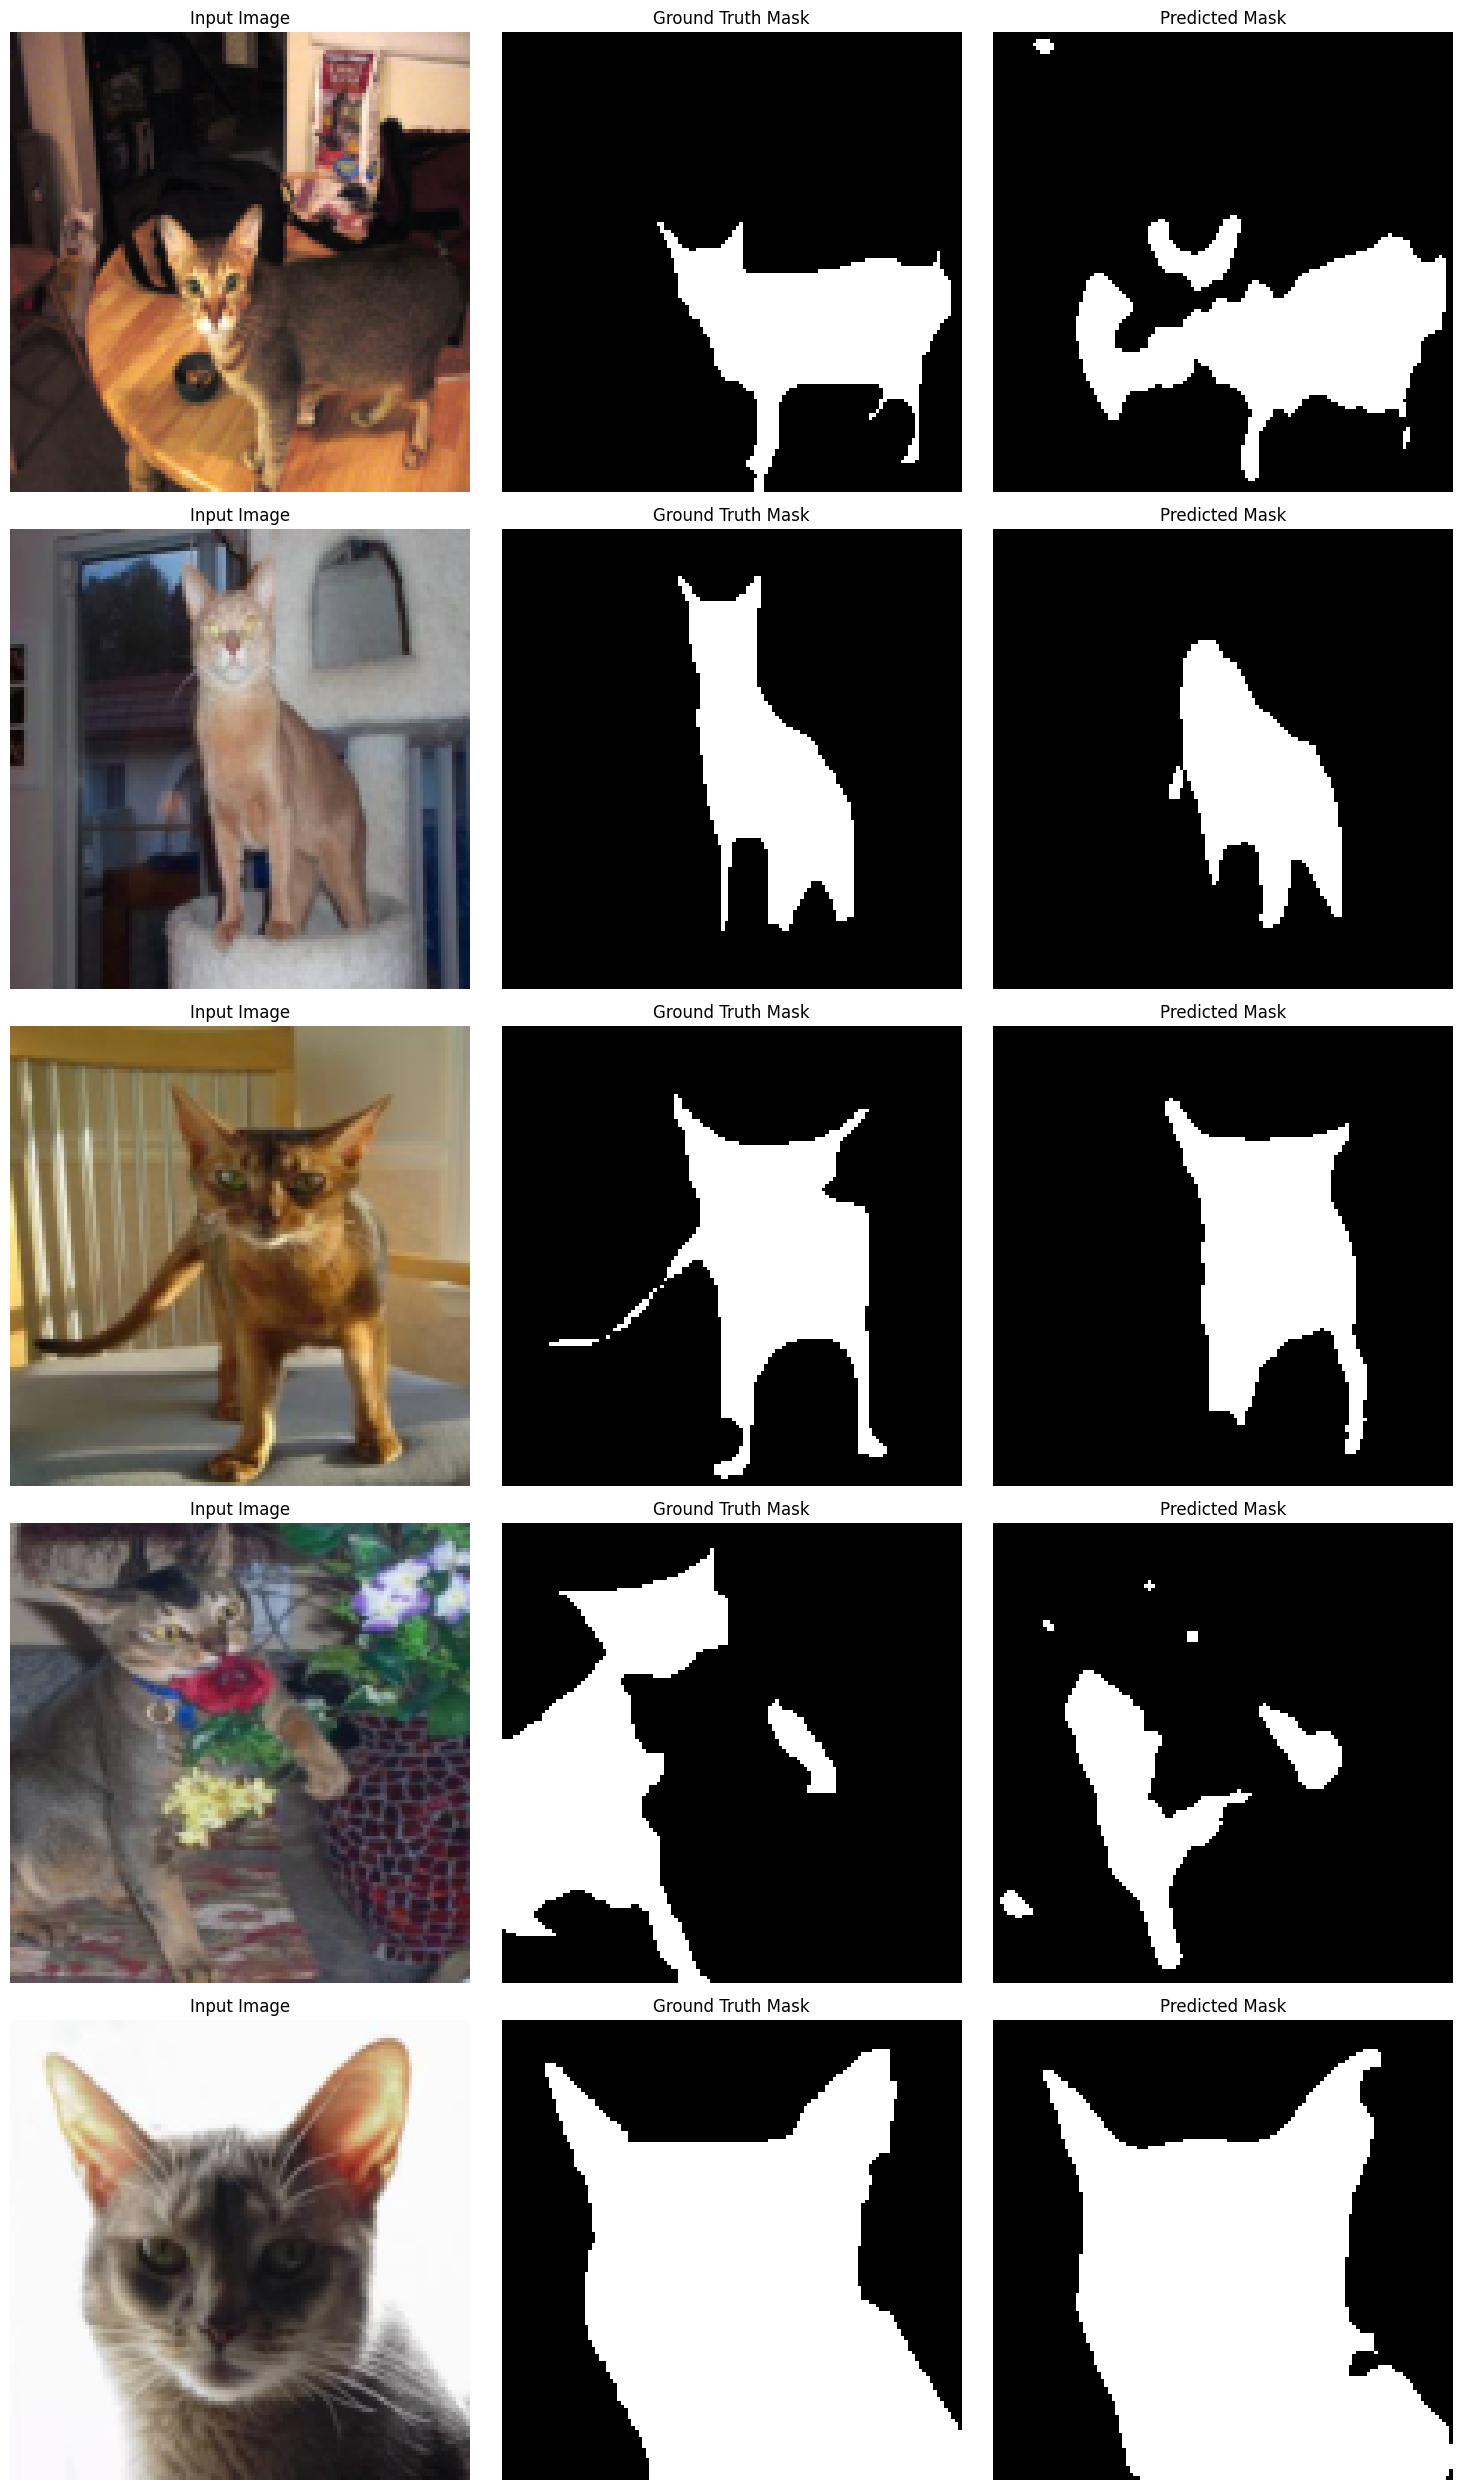

In [24]:
# --- 6. FINAL MODEL EVALUATION ON THE TEST SET ---
import torch.nn.functional as F

def calculate_segmentation_metrics(preds, targets, smooth=1e-6):
    """
    Calculates key performance metrics for semantic segmentation.
    Metrics: Dice Score, IoU (Jaccard), Pixel Accuracy, Precision, and Recall.
    """
    # Apply sigmoid to logits and threshold to get binary predictions
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    # Flatten both the predictions and targets to 1D tensors
    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)

    # Calculate True Positives, False Positives, False Negatives, and True Negatives
    tp = (preds_flat * targets_flat).sum()
    fp = preds_flat.sum() - tp
    fn = targets_flat.sum() - tp
    tn = (1 - targets_flat).sum() - fp

    # --- Metric Calculations ---
    # Dice Coefficient (F1 Score)
    dice = (2. * tp + smooth) / (2 * tp + fp + fn + smooth)

    # IoU (Jaccard Index)
    iou = (tp + smooth) / (tp + fp + fn + smooth)

    # Pixel Accuracy
    pixel_accuracy = (tp + tn + smooth) / (tp + tn + fp + fn + smooth)

    # Precision
    precision = (tp + smooth) / (tp + fp + smooth)

    # Recall (Sensitivity)
    recall = (tp + smooth) / (tp + fn + smooth)

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "pixel_accuracy": pixel_accuracy.item(),
        "precision": precision.item(),
        "recall": recall.item()
    }

def evaluate_on_test_set(model, loader, device):
    """
    Runs a full evaluation loop on the test dataset, calculating and averaging metrics.
    """
    model.eval()  # Set the model to evaluation mode
    all_metrics = {"dice": [], "iou": [], "pixel_accuracy": [], "precision": [], "recall": []}

    with torch.no_grad():  # Disable gradient calculations
        for inputs, masks in tqdm(loader, desc="Evaluating on Test Set"):
            inputs, masks = inputs.to(device), masks.to(device)
            outputs = model(inputs)

            # Calculate metrics for the current batch
            batch_metrics = calculate_segmentation_metrics(outputs, masks)

            # Append batch metrics to the list for each key
            for key in all_metrics:
                all_metrics[key].append(batch_metrics[key])

    # Calculate the average of each metric across all batches
    avg_metrics = {key: np.mean(values) for key, values in all_metrics.items()}
    return avg_metrics

# --- 1. Prepare Test Data ---
print("\n--- Preparing the Test Dataset ---")
# The 'transform' variable is already defined from your training setup
test_dataset = PetDataset(root=DATA_ROOT, split="test", transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
print(f"Successfully loaded {len(test_dataset)} images for testing.")

# --- 2. Run Evaluation ---
# The 'model' and 'device' variables are already available from the training phase
print("\n--- Starting Final Evaluation ---")
test_results = evaluate_on_test_set(model, test_loader, device)

# --- 3. Print Final Results ---
print("\n--- Test Set Evaluation Summary ---")
print(f"Dice Score (F1):    {test_results['dice']:.4f}")
print(f"IoU (Jaccard):      {test_results['iou']:.4f}")
print(f"Pixel Accuracy:     {test_results['pixel_accuracy']:.4f}")
print(f"Precision:          {test_results['precision']:.4f}")
print(f"Recall:             {test_results['recall']:.4f}")
print("-----------------------------------")

# --- 4. Visualize Predictions on Test Set ---
# We can reuse the visualization function you already wrote
print("\n--- Visualizing Model Predictions on the Test Set ---")
visualize_results(model, test_loader, device, num_images=5)